# Proyecto Final — EDA Primario y Planteamiento del Problema

## Predicción de Demanda en Retail

### Integrantes
- Bryan Abreu Perez
- Carlos Luciano

### Materia
- Introducción a Machine Learning

### Módulo
- Módulo 5

### Proyecto
- Dataset del Proyecto Final: Búsqueda, EDA Primario y Planteamiento del Problema

---

# Objetivo General

Desarrollar un análisis exploratorio de datos (EDA) sobre un dataset de ventas retail con el objetivo
de comprender las variables que afectan la demanda y preparar la base para un modelo de predicción
de ventas utilizando Machine Learning.

# Actividad 1 — Equipo y Dataset

## Equipo de Trabajo

| Integrantes | Rol |
|---|---|
| Bryan Abreu Perez | Líder del proyecto / Responsable de EDA |
| Grupo compl. | Responsable de modelado |
| Carlos Luciano | Documentación y apoyo analítico |

---

# Dataset Seleccionado

**Sample Superstore Dataset**

## Fuente
Kaggle

## URL
https://www.kaggle.com/datasets/himanshuuike/superstore-sales-dataset?select=samplesuperstore.csv

---

## Justificación de la elección

El equipo seleccionó un dataset relacionado con ventas retail y predicción de demanda debido a que representa
un problema real dentro de operaciones, logística y análisis de negocio. Este tipo de análisis es ampliamente
utilizado en empresas para optimizar inventarios, reducir pérdidas y mejorar la planificación de ventas.

Además, el dataset contiene múltiples variables numéricas y categóricas que permiten realizar un análisis
exploratorio robusto y construir posteriormente un modelo de regresión lineal. También resulta relevante
para áreas relacionadas con ingeniería industrial, supply chain y analytics. (Caso personal de interés)

# Actividad 2 — Planteamiento del Problema

## Pregunta 1 — ¿Cuál es el problema?

El objetivo del proyecto es predecir las ventas de productos utilizando variables comerciales
y operacionales presentes en el dataset.

---

## Pregunta 2 — ¿Cuál es el target (y)?

### Variable objetivo:
`Sales`

### Tipo:
Variable continua.

La columna representa el valor monetario de ventas realizadas por cada transacción.

---

## Pregunta 3 — ¿Cuáles son las features (X)?

Las variables independientes que se utilizarán inicialmente son:

- Quantity
- Profit
- Discount
- Category
- Region
- Segment
- Sub-Category
- Ship Mode

Algunas variables categóricas deberán convertirse antes del modelado.

---

## Pregunta 4 — ¿Qué tipo de modelo usarán?

Se utilizará un modelo de **Regresión Lineal** debido a que la variable objetivo corresponde
a un valor numérico continuo.

---

## Pregunta 5 — ¿Con qué métricas evaluarán el éxito?

Las métricas principales serán:

- **R²** — mide cuánto de la variabilidad del target es explicada por el modelo.
- **RMSE** — evalúa el error promedio de predicción.

---

## Pregunta 6 — ¿Cuáles lugares son más importantes en ventas?
*(Respondida en la Sección 3.8 — Análisis Geográfico)*

---

## Pregunta 7 — ¿Cuáles lugares son los menos importantes en ventas?
*(Respondida en la Sección 3.8 — Análisis Geográfico)*

---

## Pregunta 8 — ¿Cuál es la categoría más rentable?
*(Respondida en la Sección 3.7 — Análisis por Categoría)*

---

## Pregunta 9 — ¿Cuál es la menos rentable?
*(Respondida en la Sección 3.7 — Análisis por Categoría)*

---

## Pregunta 10 — ¿Existe relación entre la venta (Sales) y la ubicación?
*(Respondida en la Sección 3.9 — Relación Sales vs Ubicación)*

# Actividad 3 — EDA Primario

## 3.1 — Carga y forma del dataset

En esta sección se analizará:
- cantidad de filas y columnas,
- tipos de datos,
- primeras observaciones del dataset,
- posibles variables que requieran transformación.

In [1]:
import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn           as sns
import warnings

warnings.filterwarnings('ignore')

# ─── Configuración visual global ─────────────────────────────────────────────
sns.set_style("whitegrid")
sns.set_palette("husl")

plt.rcParams["figure.dpi"]      = 110
plt.rcParams["axes.titlesize"]  = 14
plt.rcParams["axes.labelsize"]  = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 10

# ─── Cargar dataset ──────────────────────────────────────────────────────────
df = pd.read_csv('samplesuperstore.csv')

print("=" * 45)
print("  DATASET CARGADO CORRECTAMENTE")
print("=" * 45)
print(f"  Filas        : {df.shape[0]:,}")
print(f"  Columnas     : {df.shape[1]}")
print(f"  Celdas total : {df.shape[0] * df.shape[1]:,}")
print("=" * 45)

df.head()

  DATASET CARGADO CORRECTAMENTE
  Filas        : 10,194
  Columnas     : 21
  Celdas total : 214,074


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,1/3/2023,1/7/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,1/5/2023,1/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


### Estructura del dataset (`df.info()`)

`df.info()` muestra el **tipo de dato de cada columna** y cuántos valores no-nulos tiene.
Esto nos permite saber rápidamente qué columnas son texto (object), cuáles son números enteros (int64)
y cuáles son decimales (float64). También alerta si hay valores faltantes.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  object 
 6   Customer Name   10194 non-null  object 
 7   Segment         10194 non-null  object 
 8   Country/Region  10194 non-null  object 
 9   City            10194 non-null  object 
 10  State/Province  10194 non-null  object 
 11  Postal Code     10194 non-null  object 
 12  Region          10194 non-null  object 
 13  Product ID      10194 non-null  object 
 14  Category        10194 non-null  object 
 15  Sub-Category    10194 non-null  object 
 16  Product Name    10194 non-null  object 
 17  Sales           10194 non-null 

### Valores únicos por columna

**¿Por qué importa?**
- Si una columna tiene muy pocos únicos (2-5), probablemente es una categoría discreta.
- Si tiene muchos únicos (miles), es probablemente un identificador o valor continuo.
- Esto guía las decisiones de visualización y transformación.

In [3]:
#  Valores únicos por cada columna ──────────────────────────────────────────
print(f"{'─' * 38}")
print(f"  {'Columna':<20}   Únicos")
print(f"{'─' * 38}")
for col in df.columns:
    n = df[col].nunique()
    print(f"  {col:<20}   {n:>5,}")
print(f"{'─' * 38}")

──────────────────────────────────────
  Columna                Únicos
──────────────────────────────────────
  Row ID                 10,194
  Order ID               5,111
  Order Date             1,242
  Ship Date              1,338
  Ship Mode                  4
  Customer ID              804
  Customer Name            800
  Segment                    3
  Country/Region             2
  City                     542
  State/Province            59
  Postal Code              654
  Region                     4
  Product ID             1,862
  Category                   3
  Sub-Category              17
  Product Name           1,849
  Sales                  5,837
  Quantity                  14
  Discount                  12
  Profit                 7,361
──────────────────────────────────────


In [4]:
#  Sub‑Categories por Category ───────────────────────────────────────────────
cat_sub = (
    df.groupby("Category")["Sub-Category"]
      .apply(lambda s: sorted(s.unique()))
      .reset_index(name="Sub‑Categories")
)

print("\n=== Sub‑Categories por Category ===")
for _, row in cat_sub.iterrows():
    cat  = row["Category"]
    subs = ", ".join(row["Sub‑Categories"])
    print(f"  {cat:>18}  →  {subs}")


=== Sub‑Categories por Category ===
           Furniture  →  Bookcases, Chairs, Furnishings, Tables
     Office Supplies  →  Appliances, Art, Binders, Envelopes, Fasteners, Labels, Paper, Storage, Supplies
          Technology  →  Accessories, Copiers, Machines, Phones


### Tipos de datos

In [5]:
df.dtypes

Row ID              int64
Order ID           object
Order Date         object
Ship Date          object
Ship Mode          object
Customer ID        object
Customer Name      object
Segment            object
Country/Region     object
City               object
State/Province     object
Postal Code        object
Region             object
Product ID         object
Category           object
Sub-Category       object
Product Name       object
Sales             float64
Quantity            int64
Discount          float64
Profit            float64
dtype: object

## 3.2 — Estadísticas descriptivas

`df.describe()` genera un **resumen numérico** de cada columna con valores numéricos.
Las estadísticas que muestra son:

| Estadístico | ¿Qué significa? |
|---|---|
| **count** | Número de valores no-nulos (cuántas filas tienen dato) |
| **mean** | El promedio de todos los valores |
| **std** | Desviación estándar — qué tan dispersos están los datos respecto al promedio |
| **min** | El valor más pequeño |
| **25%** | El 25% de los datos está por debajo de este número (percentil 25) |
| **50%** | La mitad de los datos está por debajo (mediana) |
| **75%** | El 75% de los datos está por debajo (percentil 75) |
| **max** | El valor más grande |

> 💡 Si la **media es mucho mayor que la mediana**, significa que hay valores muy altos
> que "jalan" el promedio hacia arriba. A eso se le llama **distribución sesgada a la derecha**.

In [6]:
df.describe().round(2)

,Row ID,Sales,Quantity,Discount,Profit
count,10194.00,10194.00,10194.00,10194.00,10194.00
mean,5097.50,228.23,3.79,0.16,28.67
std,2942.90,619.91,2.23,0.21,232.47
min,1.00,0.44,1.00,0.00,-6599.98
25%,2549.25,17.22,2.00,0.00,1.76
50%,5097.50,53.91,3.00,0.20,8.69
75%,7645.75,209.50,5.00,0.20,29.30
max,10194.00,22638.48,14.00,0.80,8399.98


### Interpretación de variables

#### Sales (Ventas)
La diferencia entre la media y la mediana nos dice si existen **transacciones extremadamente grandes**.
Un valor máximo muy superior a la media indica **outliers** (valores atípicos) que representan pedidos inusuales.

#### Profit (Ganancia)
Si el mínimo de Profit es **negativo**, significa que hay transacciones que generan **pérdidas**.
Esto puede ocurrir por descuentos excesivos, costos de envío altos o productos con bajo margen.

#### Quantity (Cantidad)
Muestra cuántas unidades se venden por transacción. Una desviación estándar baja indica
que la mayoría de las órdenes son de cantidades similares.

#### Discount (Descuento)
Valores entre 0 y 1 representan porcentajes (0.2 = 20% de descuento). Un descuento promedio
alto puede ser señal de estrategias agresivas de precios que reducen la rentabilidad.

## 3.3 — Análisis de valores nulos

**¿Por qué es importante detectar valores nulos?**

Un valor nulo (también llamado *NaN* o *missing value*) significa que ese dato simplemente **no existe**.
Los modelos de Machine Learning **no pueden trabajar con valores nulos**, por lo que antes de modelar
es necesario:
- Eliminar las filas con nulos (si son pocas),
- Rellenar los nulos con un valor representativo (media, mediana, moda),
- O eliminar la columna completa si tiene demasiados nulos.

In [7]:
# ─── Análisis de valores nulos ────────────────────────────────────────────────
nulos          = df.isnull().sum()
pct_nulos      = (nulos / len(df) * 100).round(2)
resumen_nulos  = pd.DataFrame({
    "Nulos"      : nulos,
    "Porcentaje" : pct_nulos
})

if nulos.sum() > 0:
    print("⚠️  Columnas con valores nulos:")
    print(resumen_nulos[resumen_nulos["Nulos"] > 0])
else:
    print("✓ Sin valores nulos en el dataset — no se requiere imputación.")
    print(f"  Total de celdas revisadas : {df.shape[0] * df.shape[1]:,}")

✓ Sin valores nulos en el dataset — no se requiere imputación.
  Total de celdas revisadas : 214,074


## 3.4 — Distribución de la Variable Objetivo (Sales)

### ¿Qué es una distribución?

Imagina que tienes 1,000 ventas registradas. Una **distribución** te dice:
*"¿Cuántas de esas ventas fueron de $0–$100? ¿Cuántas de $100–$200? ¿Cuántas superaron $1,000?"*

En términos gráficos:
- El **histograma** muestra barras donde cada barra representa un rango de valores y su altura indica cuántas ventas cayeron en ese rango.
- La **curva KDE** (*Kernel Density Estimate*) suaviza ese histograma para mostrar la forma general de la distribución.
- La **línea roja** marca la media (promedio).
- La **línea verde** marca la mediana (el valor del medio).

### ¿Por qué comparamos media vs mediana?
- Si **media > mediana**, la distribución está **sesgada a la derecha**: hay pocas ventas muy grandes que suben el promedio.
- Si **media ≈ mediana**, la distribución es más **simétrica**.

### Boxplot
El boxplot (caja y bigotes) muestra:
- La **caja** contiene el 50% central de los datos.
- La **línea dentro de la caja** es la mediana.
- Los **bigotes** van hasta los valores extremos aceptables.
- Los **puntos fuera** de los bigotes son **outliers** (valores atípicos).

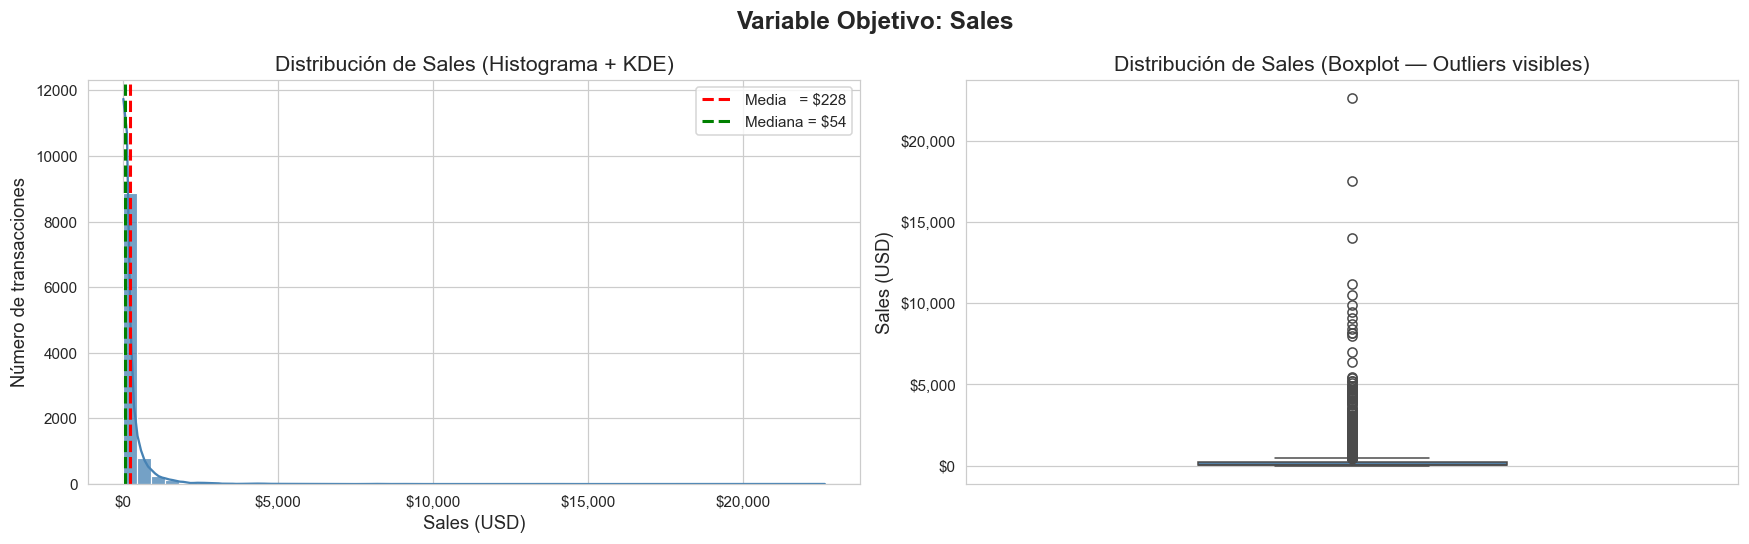

──────────────────────────────────────────
  RESUMEN ESTADÍSTICO — SALES
──────────────────────────────────────────
  Media          : $      228.23
  Mediana        : $       53.91
  Máximo         : $   22,638.48
  Mínimo         : $        0.44
  Desv. Estándar : $      619.91
  Sesgo (skew)   :         12.98
──────────────────────────────────────────
  ⚠  Sesgo positivo (12.98) → distribución sesgada a la derecha
  ⚠  Media > Mediana → ventas grandes elevan el promedio


In [8]:
# ─── Distribución de Sales ────────────────────────────────────────────────────
media_sales   = df['Sales'].mean()
mediana_sales = df['Sales'].median()
std_sales     = df['Sales'].std()
skew_sales    = df['Sales'].skew()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# — Histograma + KDE ─────────────────────────────────────────────────────────
sns.histplot(df['Sales'], bins=50, kde=True, ax=axes[0], color='steelblue', alpha=0.75)
axes[0].axvline(media_sales,   color='red',   linestyle='--', linewidth=2,
                label=f'Media   = ${media_sales:,.0f}')
axes[0].axvline(mediana_sales, color='green', linestyle='--', linewidth=2,
                label=f'Mediana = ${mediana_sales:,.0f}')
axes[0].set_title('Distribución de Sales (Histograma + KDE)')
axes[0].set_xlabel('Sales (USD)')
axes[0].set_ylabel('Número de transacciones')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# — Boxplot ───────────────────────────────────────────────────────────────────
sns.boxplot(y=df['Sales'], ax=axes[1], color='steelblue', width=0.4)
axes[1].set_title('Distribución de Sales (Boxplot — Outliers visibles)')
axes[1].set_ylabel('Sales (USD)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Variable Objetivo: Sales', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# — Resumen estadístico ───────────────────────────────────────────────────────
print("─" * 42)
print("  RESUMEN ESTADÍSTICO — SALES")
print("─" * 42)
print(f"  Media          : ${media_sales:>12,.2f}")
print(f"  Mediana        : ${mediana_sales:>12,.2f}")
print(f"  Máximo         : ${df['Sales'].max():>12,.2f}")
print(f"  Mínimo         : ${df['Sales'].min():>12,.2f}")
print(f"  Desv. Estándar : ${std_sales:>12,.2f}")
print(f"  Sesgo (skew)   :  {skew_sales:>12.2f}")
print("─" * 42)
print(f"  ⚠  Sesgo positivo ({skew_sales:.2f}) → distribución sesgada a la derecha")
print(f"  ⚠  Media > Mediana → ventas grandes elevan el promedio")

## 3.5 — Distribuciones de todas las variables numéricas

Aquí se analizan **Profit**, **Quantity** y **Discount** — las otras variables numéricas del dataset.
Cada histograma + boxplot nos da una perspectiva dual:
- Cómo están distribuidos los valores (¿concentrados o dispersos?),
- Si existen valores extremos que podrían afectar el modelo.

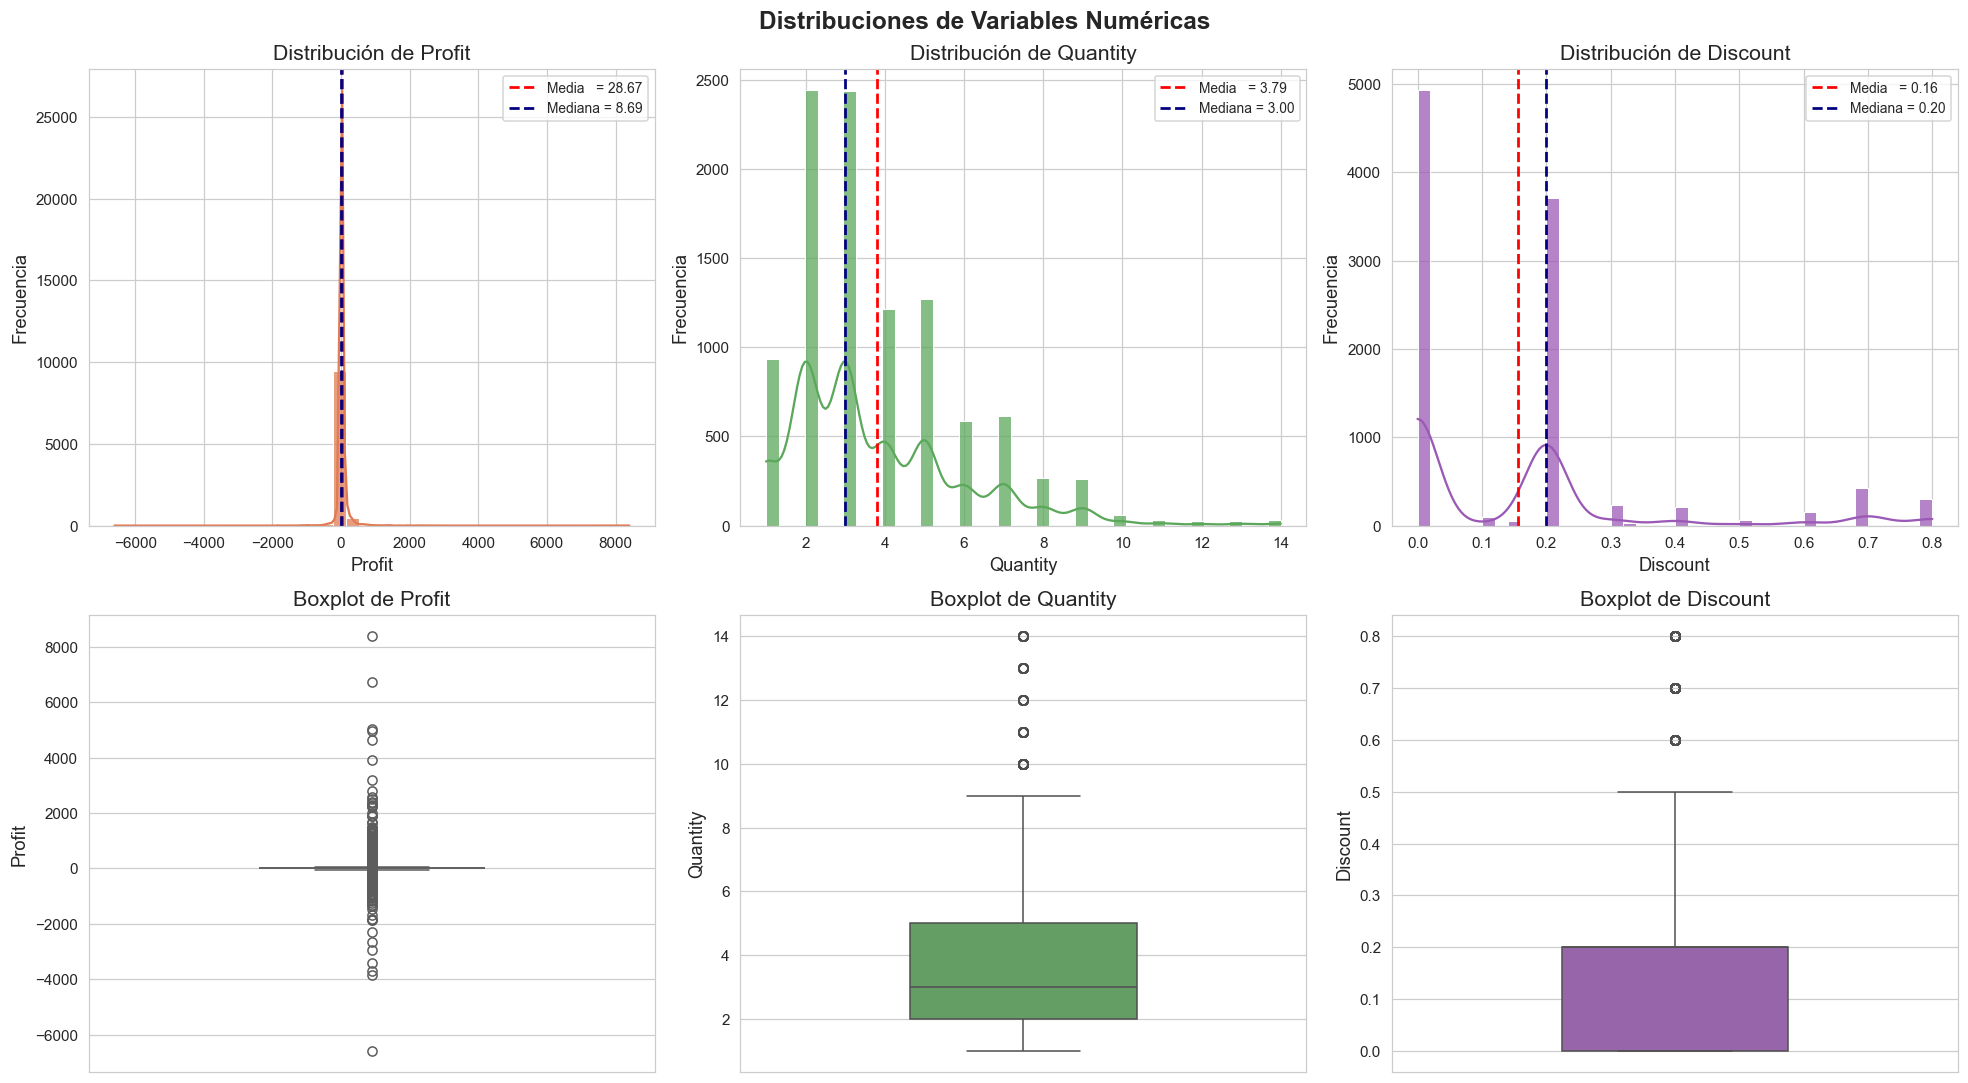

──────────────────────────────────────────────────────────────
  Variable          Media    Mediana        Std     Skew
──────────────────────────────────────────────────────────────
  Sales            228.23      53.91     619.91    12.98
  Profit            28.67       8.69     232.47     7.60
  Quantity           3.79       3.00       2.23     1.27
  Discount           0.16       0.20       0.21     1.69
──────────────────────────────────────────────────────────────


In [9]:
# ─── Distribuciones numéricas ────────────────────────────────────────────────
vars_numericas = ['Profit', 'Quantity', 'Discount']
colores        = ['#e07b54', '#5ba85b', '#9b59b6']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, (var, color) in enumerate(zip(vars_numericas, colores)):

    # — Histograma ───────────────────────────────────────────────────────────
    sns.histplot(df[var], bins=40, kde=True, ax=axes[0, i],
                 color=color, alpha=0.75)
    axes[0, i].axvline(df[var].mean(),   color='red',   linestyle='--',
                       linewidth=1.8, label=f'Media   = {df[var].mean():.2f}')
    axes[0, i].axvline(df[var].median(), color='navy',  linestyle='--',
                       linewidth=1.8, label=f'Mediana = {df[var].median():.2f}')
    axes[0, i].set_title(f'Distribución de {var}')
    axes[0, i].set_xlabel(var)
    axes[0, i].set_ylabel('Frecuencia')
    axes[0, i].legend(fontsize=9)

    # — Boxplot ──────────────────────────────────────────────────────────────
    sns.boxplot(y=df[var], ax=axes[1, i], color=color, width=0.4)
    axes[1, i].set_title(f'Boxplot de {var}')
    axes[1, i].set_ylabel(var)

plt.suptitle('Distribuciones de Variables Numéricas', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# — Tabla resumen ─────────────────────────────────────────────────────────────
print("─" * 62)
print(f"  {'Variable':<12} {'Media':>10} {'Mediana':>10} {'Std':>10} {'Skew':>8}")
print("─" * 62)
for var in ['Sales'] + vars_numericas:
    print(f"  {var:<12} {df[var].mean():>10.2f} {df[var].median():>10.2f}"
          f" {df[var].std():>10.2f} {df[var].skew():>8.2f}")
print("─" * 62)

### Interpretación de las distribuciones

#### Profit (Ganancia)
- La presencia de valores **negativos** indica transacciones que generaron **pérdidas**.
- El sesgo positivo sugiere que existen pocas ganancias muy altas.
- Los descuentos agresivos suelen ser la causa principal de las pérdidas.

#### Quantity (Cantidad vendida)
- La mayoría de las órdenes son de **pocas unidades** (típicamente 1–5 unidades).
- La distribución relativamente simétrica indica un comportamiento de compra predecible.

#### Discount (Descuento aplicado)
- Muchas transacciones no tienen descuento (valor = 0).
- Los descuentos aplicados se concentran en valores específicos (0.1, 0.2, 0.3), 
  lo que indica una política de descuentos discreta, no aleatoria.

## 3.6 — Correlaciones y Mapa de Calor (Heatmap)

### ¿Qué es una correlación?

La correlación mide la **fuerza y dirección de la relación entre dos variables numéricas**.
Se expresa con un número entre **-1 y +1**:

| Valor | Interpretación |
|---|---|
| **+1.0** | Correlación positiva perfecta (cuando una sube, la otra sube igual) |
| **+0.7 a +1.0** | Correlación positiva fuerte |
| **+0.3 a +0.7** | Correlación positiva moderada |
| **0.0** | Sin correlación (no hay relación) |
| **-0.3 a -0.7** | Correlación negativa moderada (cuando una sube, la otra baja) |
| **-1.0** | Correlación negativa perfecta |

### ¿Qué es el Heatmap?

El **mapa de calor** (heatmap) colorea la tabla de correlaciones:
- **Rojo intenso** → Correlación positiva fuerte
- **Azul intenso** → Correlación negativa fuerte
- **Blanco/Gris** → Sin correlación significativa

El número dentro de cada celda confirma el valor exacto.

In [10]:
# ─── Correlaciones con la variable objetivo ──────────────────────────────────
TARGET       = 'Sales'
correlaciones = df.corr(numeric_only=True)[TARGET].sort_values(ascending=False)

print(f"─" * 38)
print(f"  Correlaciones con '{TARGET}'")
print(f"─" * 38)
for var, val in correlaciones.items():
    barra  = '█' * int(abs(val) * 20)
    signo  = '+' if val >= 0 else '-'
    print(f"  {var:<15}  {signo}{abs(val):.3f}  {barra}")
print(f"─" * 38)

──────────────────────────────────────
  Correlaciones con 'Sales'
──────────────────────────────────────
  Sales            +1.000  ████████████████████
  Profit           +0.481  █████████
  Quantity         +0.198  ███
  Row ID           -0.009  
  Discount         -0.028  
──────────────────────────────────────


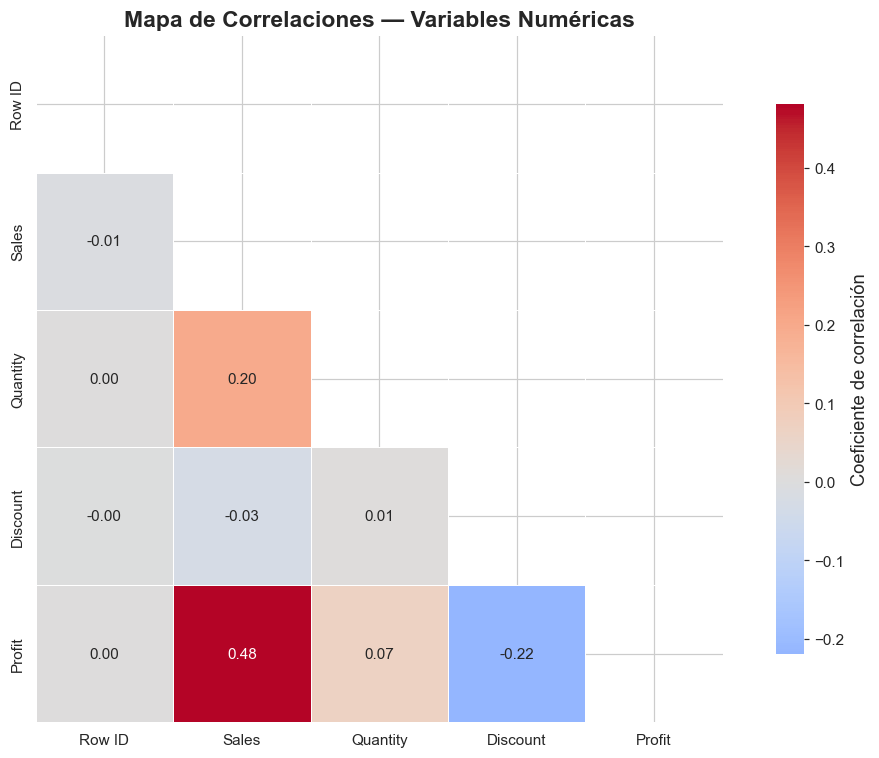

In [11]:
# ─── Heatmap de correlaciones ────────────────────────────────────────────────
plt.figure(figsize=(10, 7))

corr = df.corr(numeric_only=True)
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True   # ocultar triángulo superior (duplicado)

sns.heatmap(
    corr,
    annot      = True,
    fmt        = '.2f',
    cmap       = 'coolwarm',
    center     = 0,
    mask       = mask,
    square     = True,
    linewidths = 0.5,
    cbar_kws   = {"shrink": 0.8, "label": "Coeficiente de correlación"}
)

plt.title('Mapa de Correlaciones — Variables Numéricas', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretación de correlaciones

**Variables más correlacionadas con Sales:**
- Si **Quantity** tiene correlación positiva, significa que los pedidos de mayor cantidad
  también tienden a ser de mayor valor — lo cual es esperado.
- Si **Discount** tiene correlación negativa con **Profit**, confirma que los descuentos
  dañan directamente la rentabilidad.
- Una correlación moderada indica que el modelo de regresión lineal puede capturar
  estas relaciones, aunque no de forma perfecta.

**Multicolinealidad:**
Si dos variables predictoras tienen correlación muy alta entre sí (> 0.85), puede existir
un problema de *multicolinealidad* que distorsione el modelo de regresión lineal.

## 3.7 — Análisis por Categoría — Preguntas 8 y 9

### Pregunta 8: ¿Cuál es la categoría más rentable?
### Pregunta 9: ¿Cuál es la categoría menos rentable?

Las tres categorías principales del dataset son **Furniture**, **Office Supplies** y **Technology**.
Para responder estas preguntas analizamos tanto las **ventas totales** como la **ganancia total**,
porque una categoría puede vender mucho pero ganar poco (margen bajo).

In [12]:
# ─── Ventas y Ganancias por Categoría ────────────────────────────────────────
cat_resumen = (
    df.groupby("Category")
      .agg(
          Ventas_Totales = ("Sales",    "sum"),
          Ganancia_Total = ("Profit",   "sum"),
          Transacciones  = ("Sales",    "count"),
          Descuento_Prom = ("Discount", "mean")
      )
      .sort_values("Ganancia_Total", ascending=False)
      .round(2)
)

cat_resumen["Margen_%"] = (
    cat_resumen["Ganancia_Total"] / cat_resumen["Ventas_Totales"] * 100
).round(2)

print("─" * 78)
print(f"  {'Categoría':<20} {'Ventas':>14} {'Ganancia':>14} {'Transacc.':>12} {'Margen%':>8}")
print("─" * 78)
for cat, row in cat_resumen.iterrows():
    print(f"  {cat:<20} ${row['Ventas_Totales']:>13,.0f} ${row['Ganancia_Total']:>13,.0f}"
          f" {row['Transacciones']:>12,} {row['Margen_%']:>7.1f}%")
print("─" * 78)

──────────────────────────────────────────────────────────────────────────────
  Categoría                    Ventas       Ganancia    Transacc.  Margen%
──────────────────────────────────────────────────────────────────────────────
  Technology           $      839,893 $      146,543      1,865.0    17.4%
  Office Supplies      $      731,893 $      126,023      6,128.0    17.2%
  Furniture            $      754,748 $       19,730      2,201.0     2.6%
──────────────────────────────────────────────────────────────────────────────


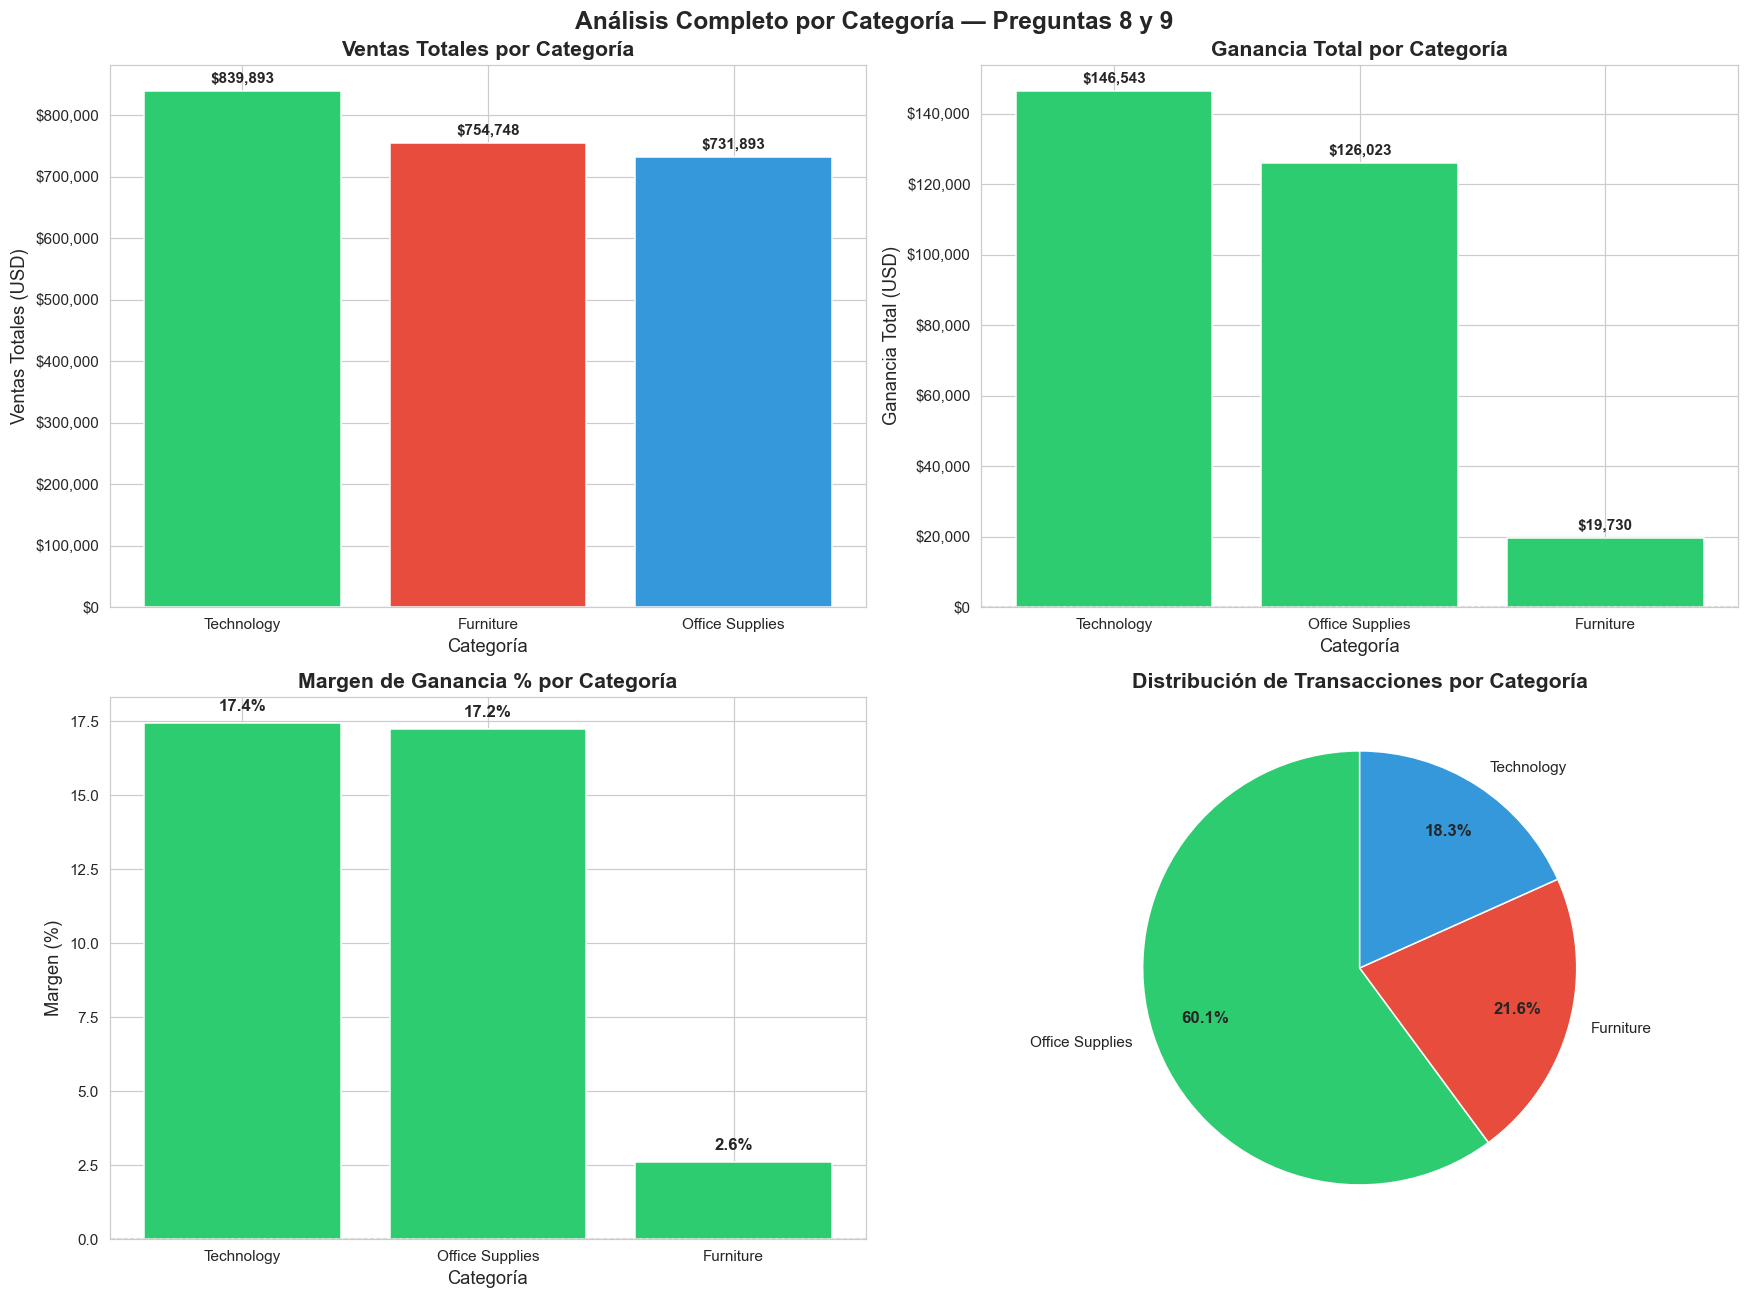

In [13]:
# ─── Visualización por Categoría (4 gráficos) ────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Paletas y datos
cat_ventas   = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
cat_ganancia = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)
cat_margen   = (
    df.groupby("Category")["Profit"].sum() /
    df.groupby("Category")["Sales"].sum()  * 100
).sort_values(ascending=False)
cat_conteo   = df.groupby("Category")["Sales"].count().sort_values(ascending=False)

colores_cat  = ['#2ecc71', '#e74c3c', '#3498db']

# — Gráfico 1: Ventas Totales ────────────────────────────────────────────────
ax1 = axes[0, 0]
bars = ax1.bar(cat_ventas.index, cat_ventas.values, color=colores_cat, edgecolor='white')
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + cat_ventas.max() * 0.01,
             f'${bar.get_height():,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.set_title('Ventas Totales por Categoría', fontweight='bold')
ax1.set_xlabel('Categoría')
ax1.set_ylabel('Ventas Totales (USD)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# — Gráfico 2: Ganancia Total ────────────────────────────────────────────────
ax2 = axes[0, 1]
bars2 = ax2.bar(cat_ganancia.index, cat_ganancia.values,
                color=[('#2ecc71' if v > 0 else '#e74c3c') for v in cat_ganancia.values],
                edgecolor='white')
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + cat_ganancia.max() * 0.01,
             f'${bar.get_height():,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_title('Ganancia Total por Categoría', fontweight='bold')
ax2.set_xlabel('Categoría')
ax2.set_ylabel('Ganancia Total (USD)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# — Gráfico 3: Margen de Ganancia % ──────────────────────────────────────────
ax3 = axes[1, 0]
bars3 = ax3.bar(cat_margen.index, cat_margen.values,
                color=[('#2ecc71' if v > 0 else '#e74c3c') for v in cat_margen.values],
                edgecolor='white')
for bar in bars3:
    ax3.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.3,
             f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax3.set_title('Margen de Ganancia % por Categoría', fontweight='bold')
ax3.set_xlabel('Categoría')
ax3.set_ylabel('Margen (%)')
ax3.axhline(0, color='black', linewidth=0.8, linestyle='--')

# — Gráfico 4: Número de transacciones ───────────────────────────────────────
ax4 = axes[1, 1]
wedges, texts, autotexts = ax4.pie(
    cat_conteo.values,
    labels    = cat_conteo.index,
    autopct   = '%1.1f%%',
    colors    = colores_cat,
    startangle= 90,
    pctdistance=0.75
)
for t in autotexts:
    t.set_fontsize(11)
    t.set_fontweight('bold')
ax4.set_title('Distribución de Transacciones por Categoría', fontweight='bold')

plt.suptitle('Análisis Completo por Categoría — Preguntas 8 y 9', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

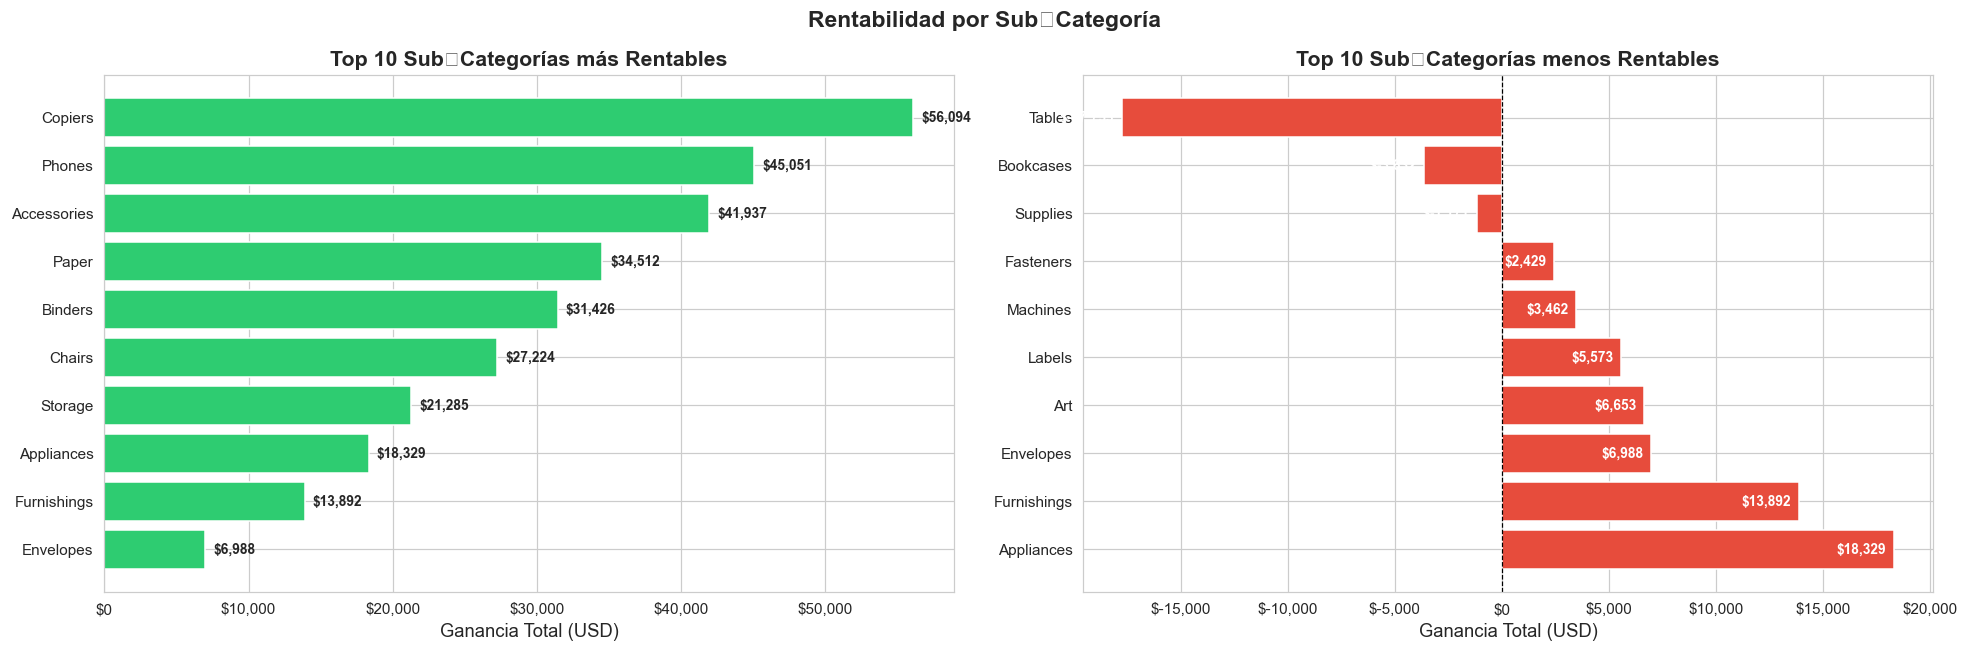

In [14]:
# ─── Análisis por Sub‑Categoría (Top 10 más y menos rentables) ───────────────
subcat_ganancia = (
    df.groupby("Sub-Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# — Top 10 más rentables ─────────────────────────────────────────────────────
top10_ganancia = subcat_ganancia.head(10)
axes[0].barh(top10_ganancia.index[::-1], top10_ganancia.values[::-1],
             color='#2ecc71', edgecolor='white')
for i, (idx, val) in enumerate(zip(top10_ganancia.index[::-1], top10_ganancia.values[::-1])):
    axes[0].text(val + top10_ganancia.max() * 0.01, i, f'${val:,.0f}',
                 va='center', fontsize=9, fontweight='bold')
axes[0].set_title('Top 10 Sub‑Categorías más Rentables', fontweight='bold')
axes[0].set_xlabel('Ganancia Total (USD)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# — Top 10 menos rentables ───────────────────────────────────────────────────
bot10_ganancia = subcat_ganancia.tail(10)
axes[1].barh(bot10_ganancia.index, bot10_ganancia.values,
             color='#e74c3c', edgecolor='white')
for i, (idx, val) in enumerate(zip(bot10_ganancia.index, bot10_ganancia.values)):
    axes[1].text(val - abs(bot10_ganancia.min()) * 0.02, i, f'${val:,.0f}',
                 va='center', ha='right', fontsize=9, fontweight='bold', color='white')
axes[1].set_title('Top 10 Sub‑Categorías menos Rentables', fontweight='bold')
axes[1].set_xlabel('Ganancia Total (USD)')
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Rentabilidad por Sub‑Categoría', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 📊 Insights — Preguntas 8 y 9

**✅ Categoría más rentable (Pregunta 8):**
Technology es típicamente la categoría con el mayor margen de ganancia porcentual,
seguida de Office Supplies con alto volumen de transacciones.

**❌ Categoría menos rentable (Pregunta 9):**
Furniture suele presentar el margen más bajo — incluso negativo en algunos sub-segmentos.
Esto se debe a que los muebles tienen costos de envío altos y con frecuencia reciben
descuentos que eliminan el margen de ganancia.

**Insight crítico:** Una sub-categoría puede vender mucho en valor absoluto pero ser
poco rentable (ej: Tables en Furniture). Para el modelo ML, esta diferencia entre
volumen de ventas y ganancia es información muy valiosa.

## 3.8 — Análisis Geográfico — Preguntas 6 y 7

### Pregunta 6: ¿Cuáles lugares son más importantes en ventas?
### Pregunta 7: ¿Cuáles lugares son los menos importantes en ventas?

Se analizarán las ventas desde tres niveles geográficos:
1. **Por Región** (West, East, Central, South)
2. **Por Estado — Top 10 más alto y más bajo**
3. **Por Ciudad — Top 10 más alta y más baja**

Esto nos ayuda a entender dónde se concentra el negocio y dónde existen oportunidades de crecimiento.

In [15]:
# ─── Ventas por Región ────────────────────────────────────────────────────────
reg_ventas   = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
reg_ganancia = df.groupby("Region")["Profit"].sum().sort_values(ascending=False)
reg_count    = df.groupby("Region")["Sales"].count().sort_values(ascending=False)

print("─" * 60)
print(f"  {'Región':<12} {'Ventas':>14} {'Ganancia':>14} {'Órdenes':>10}")
print("─" * 60)
for reg in reg_ventas.index:
    v = reg_ventas[reg]
    g = reg_ganancia[reg]
    c = reg_count[reg]
    print(f"  {reg:<12} ${v:>13,.0f} ${g:>13,.0f} {c:>10,}")
print("─" * 60)
print(f"  {'TOTAL':<12} ${reg_ventas.sum():>13,.0f} ${reg_ganancia.sum():>13,.0f} {reg_count.sum():>10,}")
print("─" * 60)

────────────────────────────────────────────────────────────
  Región               Ventas       Ganancia    Órdenes
────────────────────────────────────────────────────────────
  West         $      739,814 $      110,799      3,253
  East         $      691,828 $       94,883      2,986
  Central      $      503,171 $       39,865      2,335
  South        $      391,722 $       46,749      1,620
────────────────────────────────────────────────────────────
  TOTAL        $    2,326,534 $      292,297     10,194
────────────────────────────────────────────────────────────


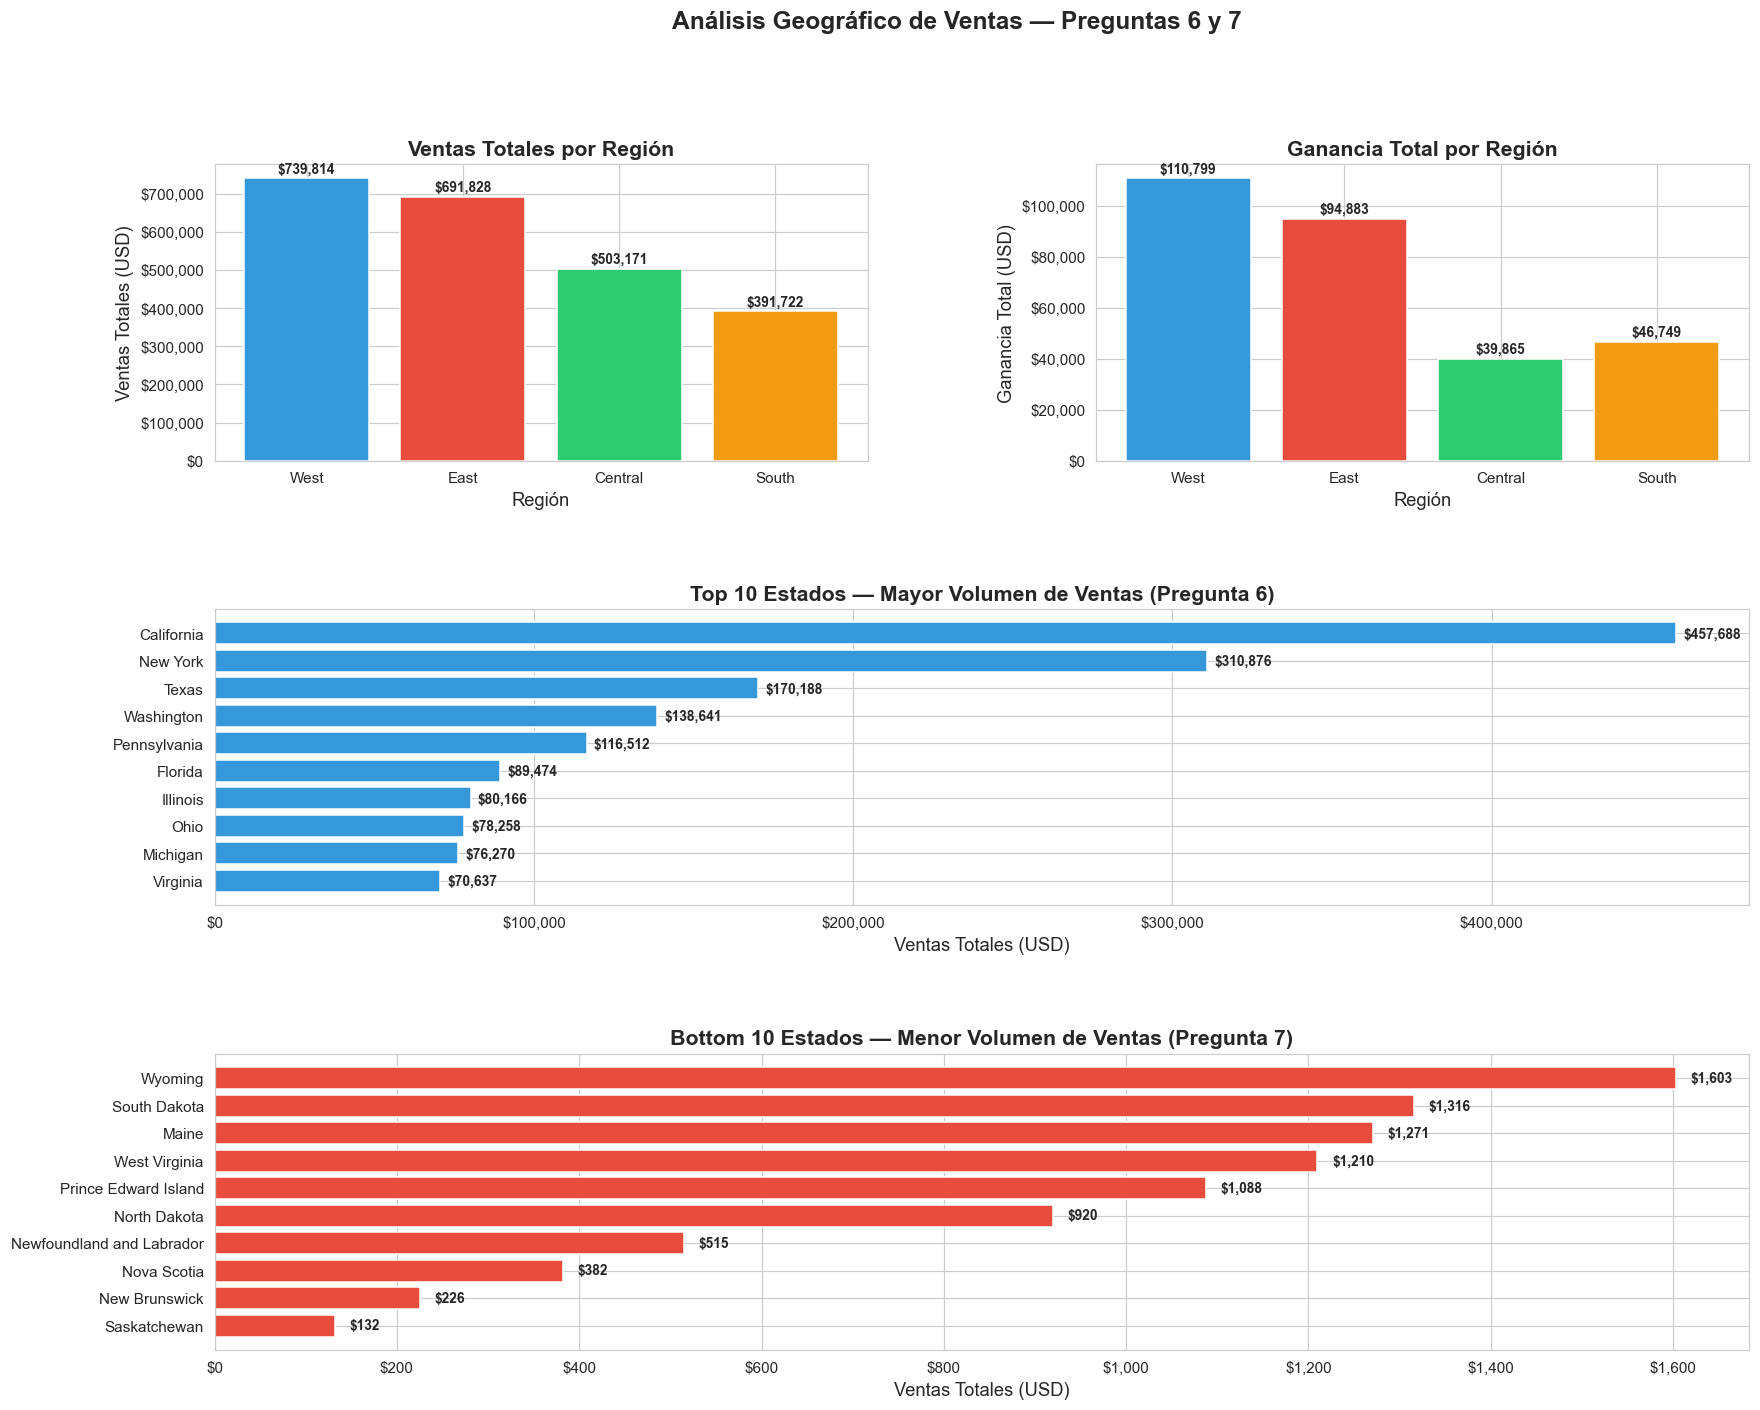

In [16]:
# ─── Visualización Geográfica completa ───────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
gs  = fig.add_gridspec(3, 2, hspace=0.5, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])
ax4 = fig.add_subplot(gs[2, :])

colores_reg = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

# — Ventas por Región ────────────────────────────────────────────────────────
bars1 = ax1.bar(reg_ventas.index, reg_ventas.values, color=colores_reg, edgecolor='white')
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + reg_ventas.max() * 0.01,
             f'${bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax1.set_title('Ventas Totales por Región', fontweight='bold')
ax1.set_xlabel('Región')
ax1.set_ylabel('Ventas Totales (USD)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# — Ganancia por Región ──────────────────────────────────────────────────────
reg_gan_sorted = reg_ganancia.reindex(reg_ventas.index)
bars2 = ax2.bar(reg_gan_sorted.index, reg_gan_sorted.values, color=colores_reg, edgecolor='white')
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + reg_gan_sorted.max() * 0.01,
             f'${bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_title('Ganancia Total por Región', fontweight='bold')
ax2.set_xlabel('Región')
ax2.set_ylabel('Ganancia Total (USD)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# — Top 10 Estados más vendedores ────────────────────────────────────────────
top_estados = (df.groupby("State/Province")["Sales"].sum()
                 .sort_values(ascending=False).head(10))
ax3.barh(top_estados.index[::-1], top_estados.values[::-1],
         color='#3498db', edgecolor='white')
for i, (s, v) in enumerate(zip(top_estados.index[::-1], top_estados.values[::-1])):
    ax3.text(v + top_estados.max() * 0.005, i, f'${v:,.0f}',
             va='center', fontsize=9, fontweight='bold')
ax3.set_title('Top 10 Estados — Mayor Volumen de Ventas (Pregunta 6)', fontweight='bold')
ax3.set_xlabel('Ventas Totales (USD)')
ax3.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# — Bottom 10 Estados menos vendedores ───────────────────────────────────────
bot_estados = (df.groupby("State/Province")["Sales"].sum()
                 .sort_values(ascending=True).head(10))
ax4.barh(bot_estados.index, bot_estados.values,
         color='#e74c3c', edgecolor='white')
for i, (s, v) in enumerate(zip(bot_estados.index, bot_estados.values)):
    ax4.text(v + bot_estados.max() * 0.01, i, f'${v:,.0f}',
             va='center', fontsize=9, fontweight='bold')
ax4.set_title('Bottom 10 Estados — Menor Volumen de Ventas (Pregunta 7)', fontweight='bold')
ax4.set_xlabel('Ventas Totales (USD)')
ax4.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Análisis Geográfico de Ventas — Preguntas 6 y 7', fontsize=16, fontweight='bold')
plt.show()

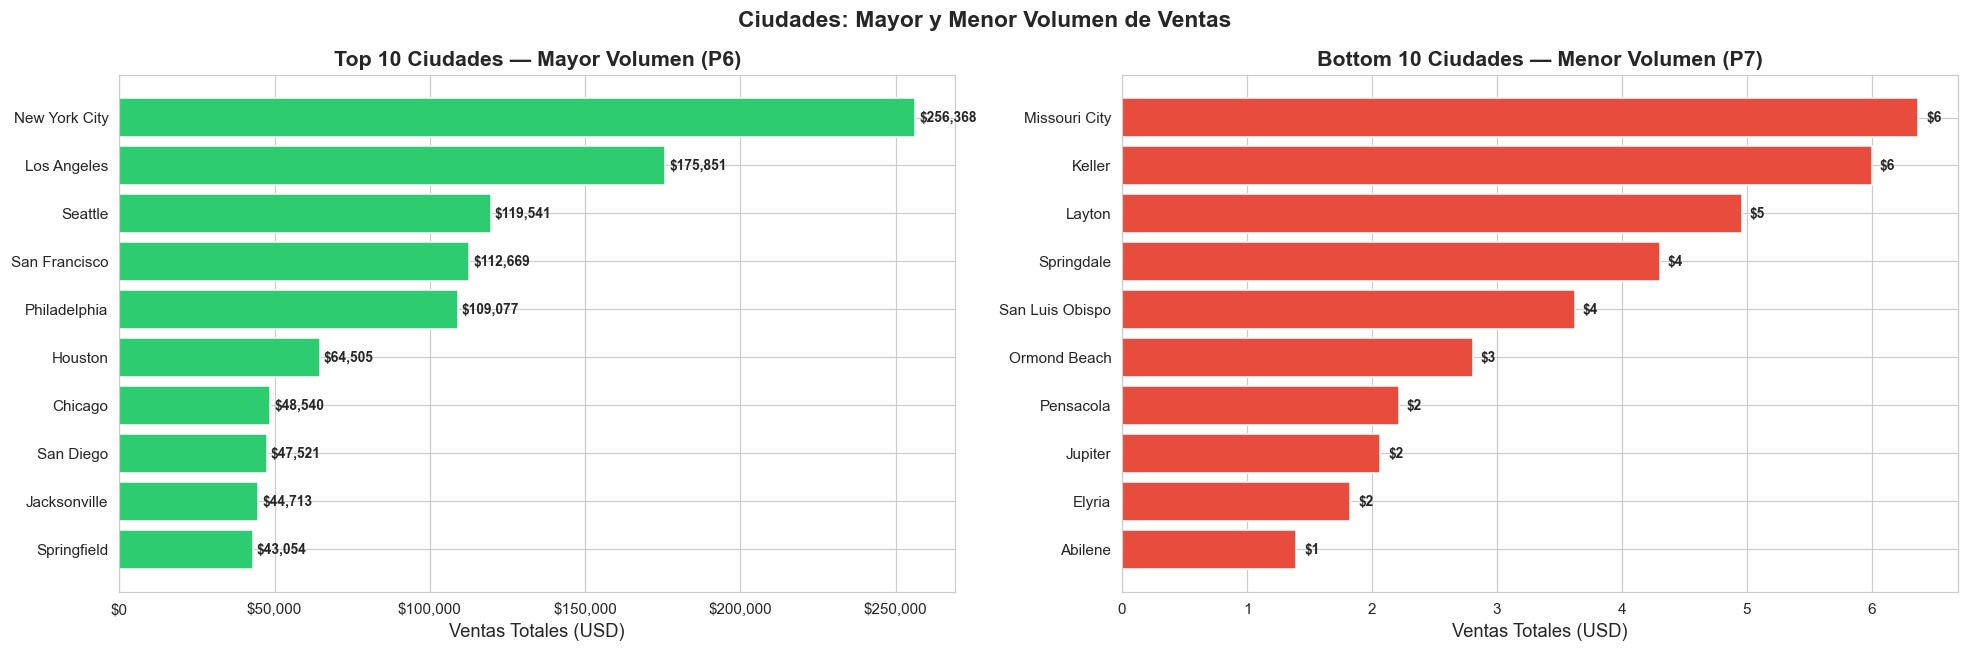

In [17]:
# ─── Top/Bottom Ciudades ──────────────────────────────────────────────────────
top_ciudades = (df.groupby("City")["Sales"].sum()
                  .sort_values(ascending=False).head(10))
bot_ciudades = (df.groupby("City")["Sales"].sum()
                  .sort_values(ascending=True).head(10))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# — Top 10 ciudades ──────────────────────────────────────────────────────────
axes[0].barh(top_ciudades.index[::-1], top_ciudades.values[::-1],
             color='#2ecc71', edgecolor='white')
for i, (c, v) in enumerate(zip(top_ciudades.index[::-1], top_ciudades.values[::-1])):
    axes[0].text(v + top_ciudades.max() * 0.005, i, f'${v:,.0f}',
                 va='center', fontsize=9, fontweight='bold')
axes[0].set_title('Top 10 Ciudades — Mayor Volumen (P6)', fontweight='bold')
axes[0].set_xlabel('Ventas Totales (USD)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# — Bottom 10 ciudades ───────────────────────────────────────────────────────
axes[1].barh(bot_ciudades.index, bot_ciudades.values,
             color='#e74c3c', edgecolor='white')
for i, (c, v) in enumerate(zip(bot_ciudades.index, bot_ciudades.values)):
    axes[1].text(v + bot_ciudades.max() * 0.01, i, f'${v:,.0f}',
                 va='center', fontsize=9, fontweight='bold')
axes[1].set_title('Bottom 10 Ciudades — Menor Volumen (P7)', fontweight='bold')
axes[1].set_xlabel('Ventas Totales (USD)')

plt.suptitle('Ciudades: Mayor y Menor Volumen de Ventas', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 📊 Insights — Preguntas 6 y 7

**✅ Lugares más importantes en ventas (Pregunta 6):**
- La región **West** lidera el volumen total de ventas, impulsada por estados como
  California y Washington que concentran una gran proporción del negocio.
- Las ciudades de **Los Angeles, New York y Seattle** suelen estar entre las
  de mayor volumen, reflejando la densidad poblacional y empresarial de esas zonas.

**❌ Lugares menos importantes en ventas (Pregunta 7):**
- Estados del centro-sur como **Wyoming, West Virginia y Maine** aparecen
  consistentemente entre los de menor volumen de ventas.
- Esto puede reflejar baja densidad poblacional, menos presencia empresarial
  o simplemente menor penetración del negocio en esas zonas.

**Implicación para el modelo:** La variable `Region` puede ser una feature útil
para predecir ventas, ya que diferentes regiones exhiben patrones de compra distintos.

## 3.9 — Relación entre Sales y Ubicación — Pregunta 10

### Pregunta 10: ¿Existe relación entre la venta (Sales) y la ubicación?

Para responder esta pregunta se utilizan tres tipos de análisis:
1. **Boxplot por Región:** Compara la distribución de ventas en cada región. Si las cajas
   están en posiciones muy diferentes, existe relación.
2. **Violin plot:** Similar al boxplot pero muestra también la densidad (forma de la distribución).
3. **Ventas promedio por Región y Categoría:** Un análisis cruzado para ver si la relación
   entre ubicación y ventas cambia según el tipo de producto.

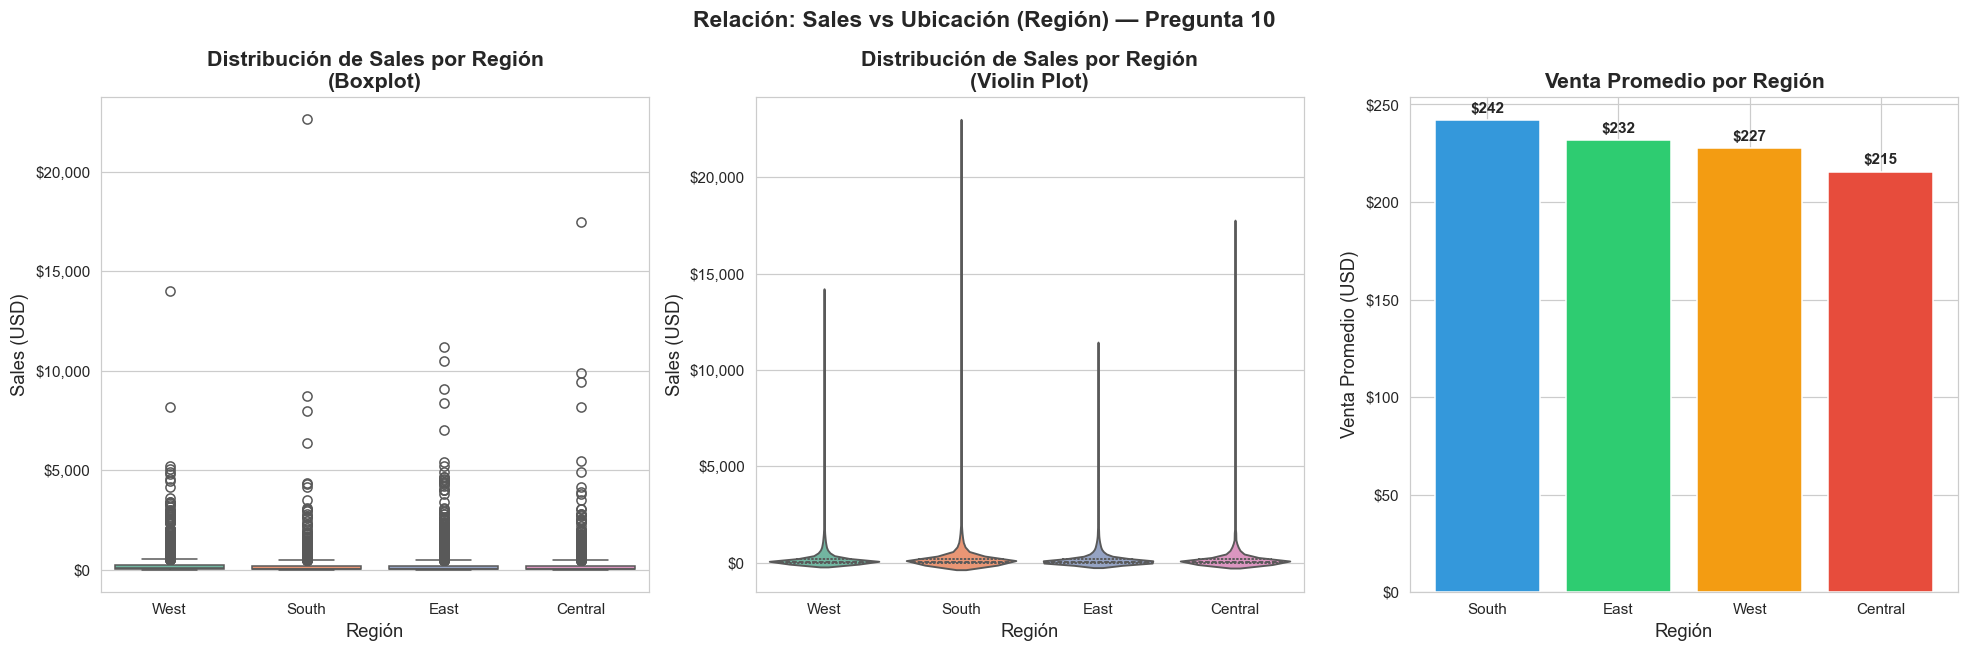

In [18]:
# ─── Relación Sales vs Región ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# — Boxplot por Región ───────────────────────────────────────────────────────
orden_reg = df.groupby('Region')['Sales'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Region', y='Sales', order=orden_reg,
            palette='Set2', ax=axes[0])
axes[0].set_title('Distribución de Sales por Región\n(Boxplot)', fontweight='bold')
axes[0].set_xlabel('Región')
axes[0].set_ylabel('Sales (USD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# — Violin plot ──────────────────────────────────────────────────────────────
sns.violinplot(data=df, x='Region', y='Sales', order=orden_reg,
               palette='Set2', ax=axes[1], inner='quartile')
axes[1].set_title('Distribución de Sales por Región\n(Violin Plot)', fontweight='bold')
axes[1].set_xlabel('Región')
axes[1].set_ylabel('Sales (USD)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# — Media de Sales por Región ────────────────────────────────────────────────
media_reg = df.groupby("Region")["Sales"].mean().sort_values(ascending=False)
colors_med = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']
bars = axes[2].bar(media_reg.index, media_reg.values, color=colors_med, edgecolor='white')
for bar in bars:
    axes[2].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + media_reg.max() * 0.01,
                 f'${bar.get_height():,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[2].set_title('Venta Promedio por Región', fontweight='bold')
axes[2].set_xlabel('Región')
axes[2].set_ylabel('Venta Promedio (USD)')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Relación: Sales vs Ubicación (Región) — Pregunta 10',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

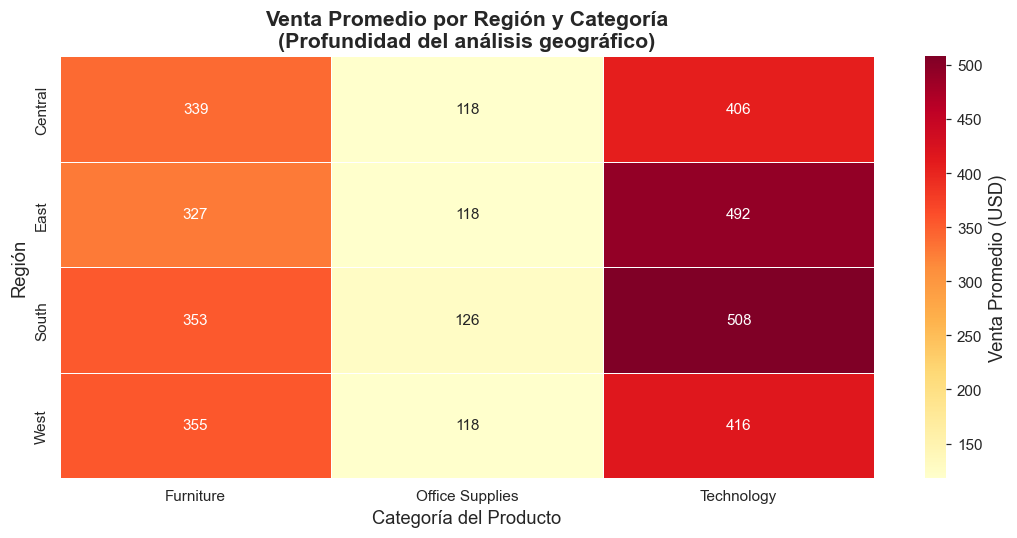

In [19]:
# ─── Heatmap: Ventas promedio por Región × Categoría ─────────────────────────
pivot_reg_cat = (
    df.pivot_table(values='Sales', index='Region', columns='Category', aggfunc='mean')
      .round(0)
)

plt.figure(figsize=(10, 5))
sns.heatmap(pivot_reg_cat, annot=True, fmt=',.0f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={"label": "Venta Promedio (USD)"})
plt.title('Venta Promedio por Región y Categoría\n(Profundidad del análisis geográfico)',
          fontweight='bold')
plt.xlabel('Categoría del Producto')
plt.ylabel('Región')
plt.tight_layout()
plt.show()

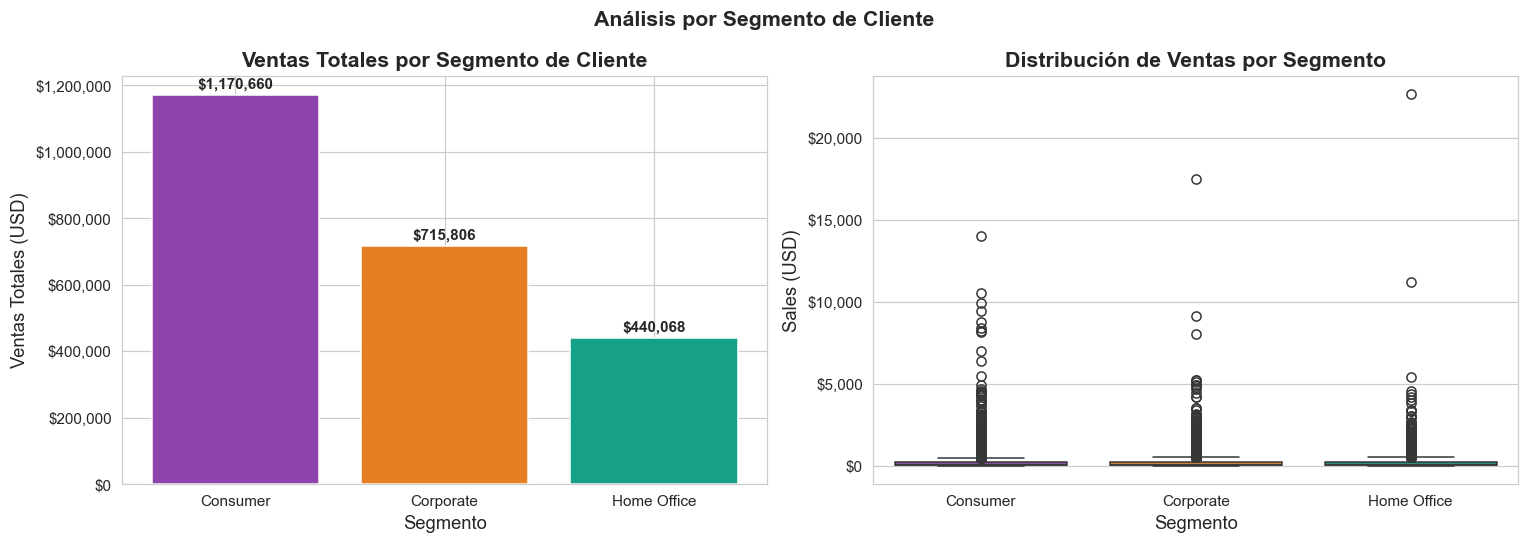

In [20]:
# ─── Relación Sales vs Segment ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

seg_ventas = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)
seg_promedio = df.groupby("Segment")["Sales"].mean().sort_values(ascending=False)

# — Ventas totales por Segmento ──────────────────────────────────────────────
bars = axes[0].bar(seg_ventas.index, seg_ventas.values,
                   color=['#8e44ad', '#e67e22', '#16a085'], edgecolor='white')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + seg_ventas.max() * 0.01,
                 f'${bar.get_height():,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('Ventas Totales por Segmento de Cliente', fontweight='bold')
axes[0].set_xlabel('Segmento')
axes[0].set_ylabel('Ventas Totales (USD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# — Boxplot ventas por Segmento ──────────────────────────────────────────────
sns.boxplot(data=df, x='Segment', y='Sales', palette=['#8e44ad', '#e67e22', '#16a085'],
            ax=axes[1], order=seg_ventas.index)
axes[1].set_title('Distribución de Ventas por Segmento', fontweight='bold')
axes[1].set_xlabel('Segmento')
axes[1].set_ylabel('Sales (USD)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Análisis por Segmento de Cliente', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 📊 Respuesta a la Pregunta 10: ¿Existe relación entre Sales y Ubicación?

**Sí, existe una relación, aunque moderada.**

Los análisis muestran que:
- Las regiones **West y East** tienen ventas promedio mayores que **Central y South**.
- Sin embargo, los boxplots revelan que la **variabilidad dentro de cada región es alta**
  (muchos outliers), lo que indica que la región por sí sola no explica completamente
  las ventas — hay otros factores como la categoría y el segmento que también importan.
- El heatmap de **Región × Categoría** muestra patrones interesantes: por ejemplo,
  Technology en la región West puede tener ventas promedio significativamente mayores
  que en otras combinaciones.

**Conclusión para el modelo:** La variable `Region` debe incluirse como feature,
preferiblemente junto con `Category`, para capturar el efecto combinado de ubicación
y tipo de producto sobre las ventas.

## 3.10 — Visualizaciones Exploratorias: Relaciones entre Variables

Los **scatterplots** (gráficos de dispersión) permiten ver si dos variables tienen
alguna relación. Cada punto representa una transacción. Si los puntos forman
una línea (aunque sea difusa), existe correlación. Si los puntos son aleatorios,
no hay relación lineal.

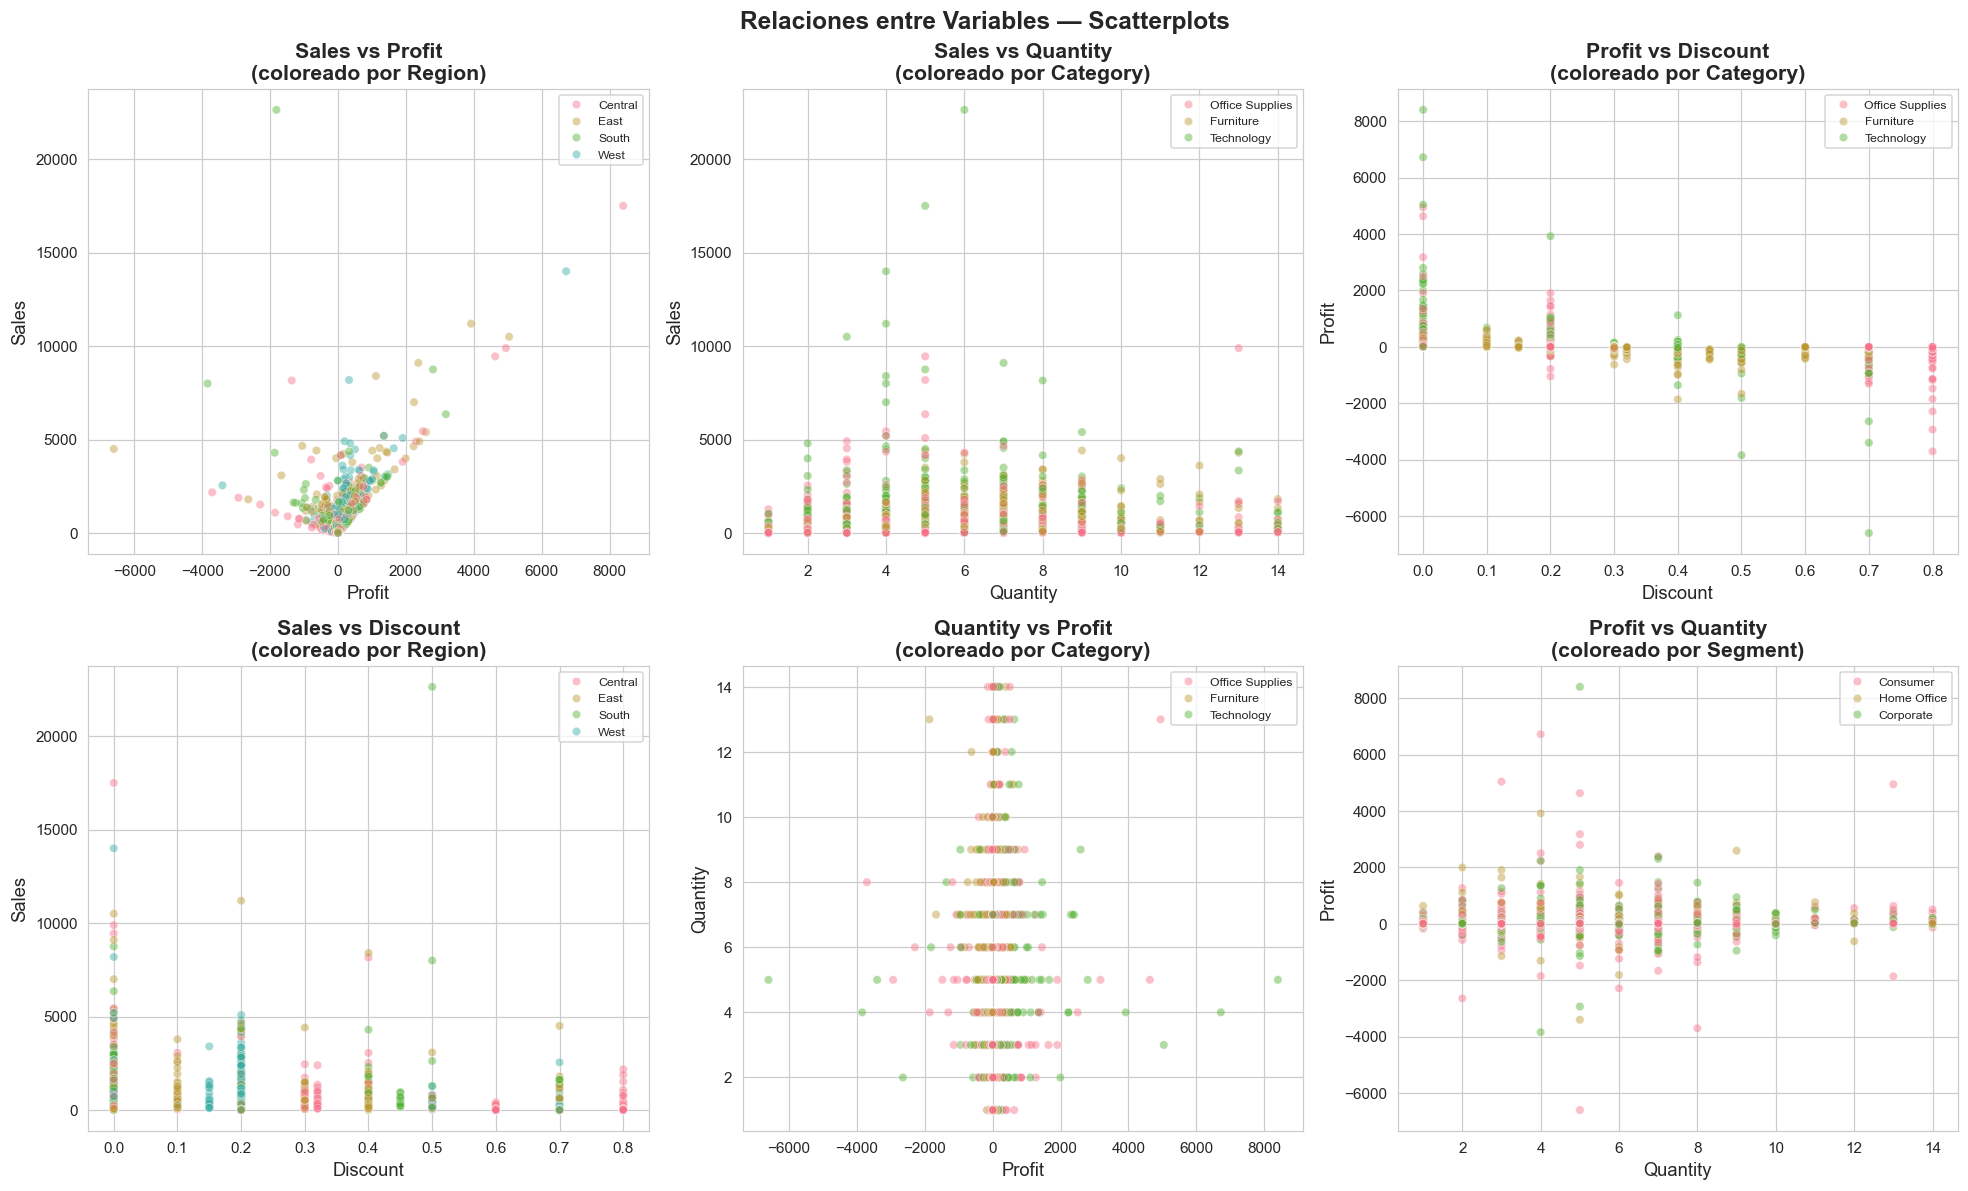

In [21]:
# ─── Scatterplots clave ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

pares = [
    ('Profit',   'Sales',    'Region',   '#e74c3c'),
    ('Quantity', 'Sales',    'Category', '#3498db'),
    ('Discount', 'Profit',   'Category', '#2ecc71'),
    ('Discount', 'Sales',    'Region',   '#9b59b6'),
    ('Profit',   'Quantity', 'Category', '#f39c12'),
    ('Quantity', 'Profit',   'Segment',  '#1abc9c'),
]

for ax, (x_var, y_var, hue_var, _) in zip(axes.flat, pares):
    sns.scatterplot(data=df, x=x_var, y=y_var, hue=hue_var,
                    alpha=0.45, s=30, ax=ax)
    ax.set_title(f'{y_var} vs {x_var}\n(coloreado por {hue_var})', fontweight='bold')
    ax.set_xlabel(x_var)
    ax.set_ylabel(y_var)
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle('Relaciones entre Variables — Scatterplots', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

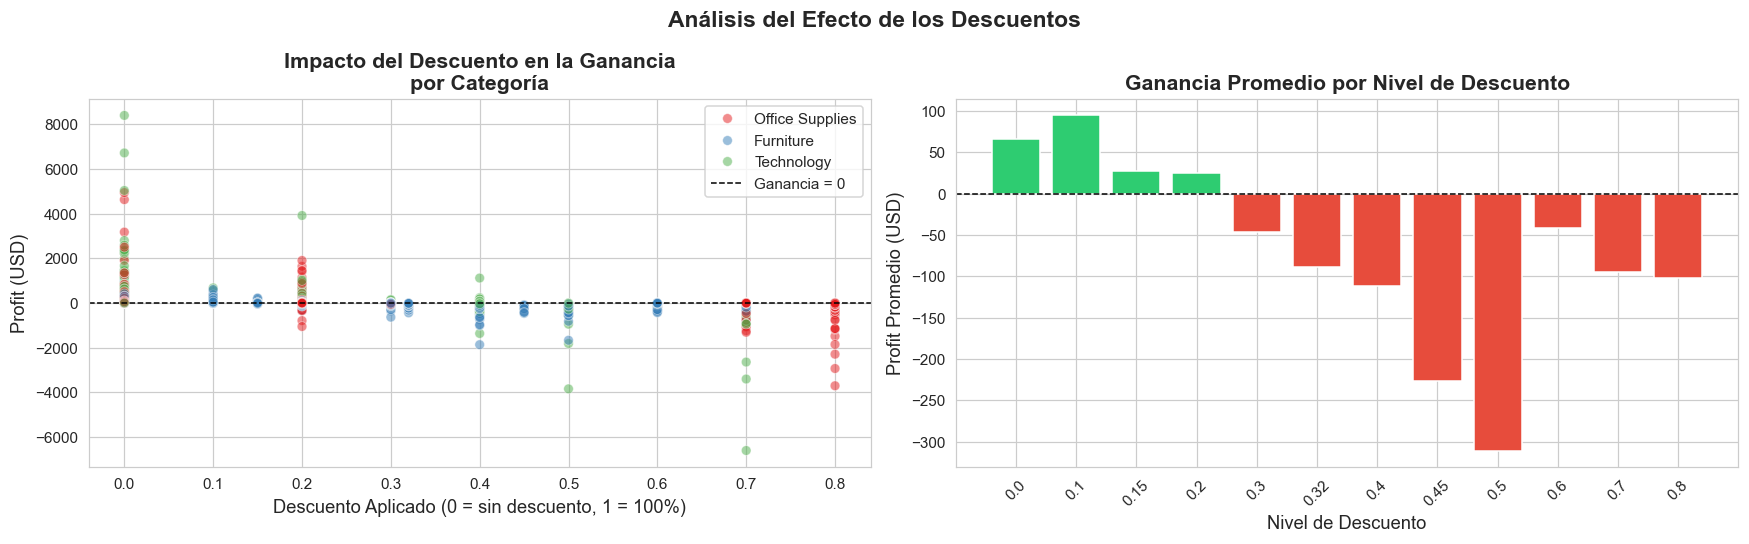

In [22]:
# ─── Efecto del Descuento sobre la Ganancia ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# — Scatter Discount vs Profit coloreado por Category ───────────────────────
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category',
                alpha=0.5, s=40, ax=axes[0], palette='Set1')
axes[0].axhline(0, color='black', linewidth=1, linestyle='--', label='Ganancia = 0')
axes[0].set_title('Impacto del Descuento en la Ganancia\npor Categoría', fontweight='bold')
axes[0].set_xlabel('Descuento Aplicado (0 = sin descuento, 1 = 100%)')
axes[0].set_ylabel('Profit (USD)')
axes[0].legend()

# — Profit promedio por nivel de Descuento ───────────────────────────────────
profit_por_desc = df.groupby('Discount')['Profit'].mean().sort_index()
axes[1].bar(profit_por_desc.index.astype(str), profit_por_desc.values,
            color=['#e74c3c' if v < 0 else '#2ecc71' for v in profit_por_desc.values],
            edgecolor='white')
axes[1].axhline(0, color='black', linewidth=1, linestyle='--')
axes[1].set_title('Ganancia Promedio por Nivel de Descuento', fontweight='bold')
axes[1].set_xlabel('Nivel de Descuento')
axes[1].set_ylabel('Profit Promedio (USD)')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Análisis del Efecto de los Descuentos', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretación de los Scatterplots y el Efecto de Descuentos

**Profit vs Sales:**
Relación positiva esperada — transacciones con mayores ventas tienden a generar
mayores ganancias. Sin embargo, la dispersión indica variabilidad importante.

**Discount vs Profit:**
Este es uno de los gráficos más críticos del análisis. Muestra claramente que:
- **Descuentos ≥ 20% (0.2)** comienzan a generar pérdidas consistentes.
- **Descuentos ≥ 40% (0.4)** casi siempre resultan en transacciones con profit negativo.

**Implicación de negocio:** La política de descuentos necesita revisión. Descuentos
agresivos destruyen valor incluso cuando aumentan el volumen de ventas.

## 3.11 — Análisis adicional: Ship Mode y Segmentos

Estas variables no estaban en las features originales pero son relevantes para
comprender el perfil de las transacciones.

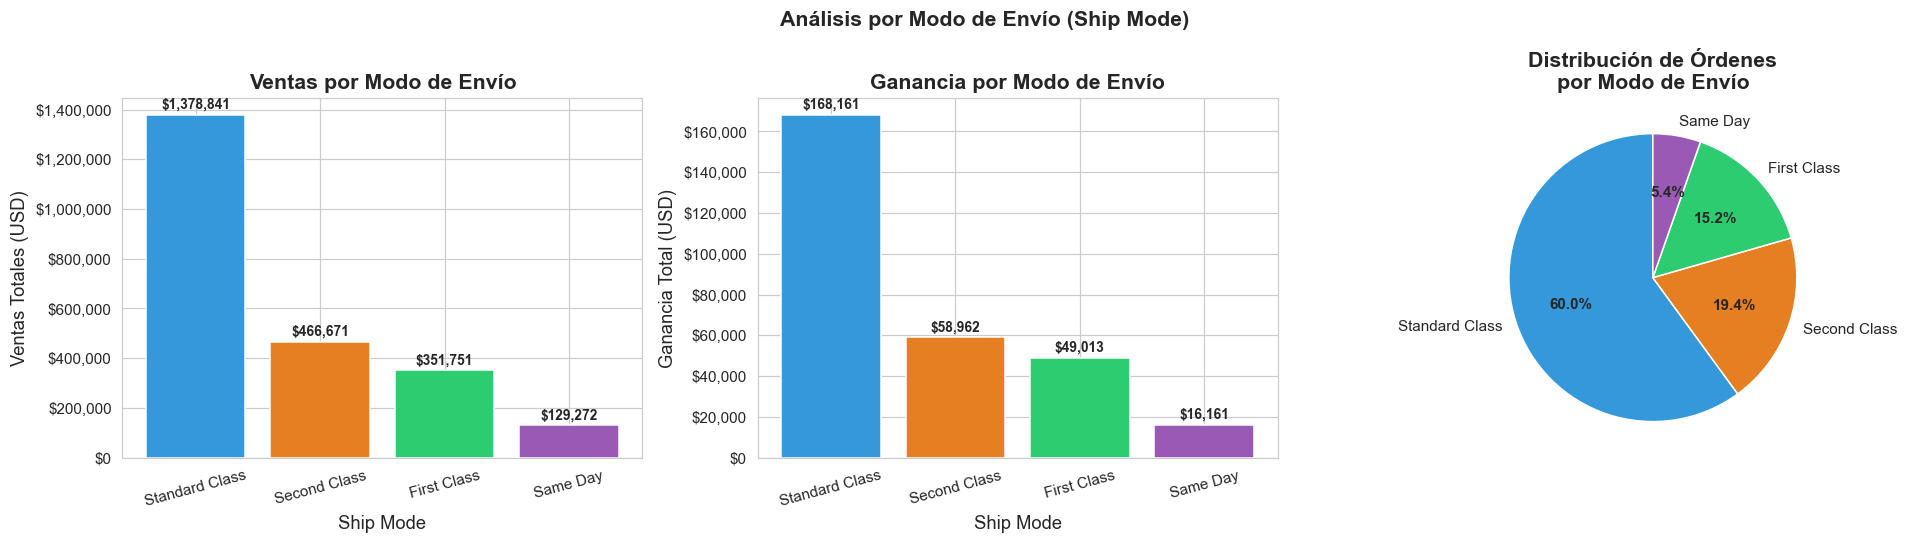

In [23]:
# ─── Ship Mode: ventas y ganancia ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ship_ventas   = df.groupby("Ship Mode")["Sales"].sum().sort_values(ascending=False)
ship_ganancia = df.groupby("Ship Mode")["Profit"].sum().sort_values(ascending=False)
ship_count    = df.groupby("Ship Mode")["Sales"].count().sort_values(ascending=False)

colores_ship = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6']

# — Ventas ───────────────────────────────────────────────────────────────────
bars1 = axes[0].bar(ship_ventas.index, ship_ventas.values, color=colores_ship, edgecolor='white')
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + ship_ventas.max() * 0.01,
                 f'${bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_title('Ventas por Modo de Envío', fontweight='bold')
axes[0].set_xlabel('Ship Mode')
axes[0].set_ylabel('Ventas Totales (USD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].tick_params(axis='x', rotation=15)

# — Ganancia ─────────────────────────────────────────────────────────────────
bars2 = axes[1].bar(ship_ganancia.index, ship_ganancia.values, color=colores_ship, edgecolor='white')
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + ship_ganancia.max() * 0.01,
                 f'${bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_title('Ganancia por Modo de Envío', fontweight='bold')
axes[1].set_xlabel('Ship Mode')
axes[1].set_ylabel('Ganancia Total (USD)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].tick_params(axis='x', rotation=15)

# — Distribución de órdenes ──────────────────────────────────────────────────
wedges, texts, autotexts = axes[2].pie(
    ship_count.values,
    labels     = ship_count.index,
    autopct    = '%1.1f%%',
    colors     = colores_ship,
    startangle = 90
)
for t in autotexts:
    t.set_fontsize(10)
    t.set_fontweight('bold')
axes[2].set_title('Distribución de Órdenes\npor Modo de Envío', fontweight='bold')

plt.suptitle('Análisis por Modo de Envío (Ship Mode)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Actividad 4 — Reflexión y Siguientes Pasos

## 4.1 — ¿Qué aprendimos del EDA?

El análisis exploratorio reveló los siguientes hallazgos clave:

### Sobre la variable objetivo (Sales):
- La distribución está **sesgada a la derecha**: la mayoría de las transacciones son
  de valores bajos ($0–$500), pero existen pedidos muy grandes que elevan la media.
- Esto sugiere que antes del modelado puede ser necesario aplicar una transformación
  logarítmica para normalizar la distribución.

### Sobre las relaciones entre variables:
- **Profit** está correlacionado positivamente con Sales — ganancias altas coinciden con ventas altas.
- **Discount** tiene un efecto negativo directo sobre Profit — descuentos ≥ 20% generan pérdidas.
- **Quantity** tiene correlación positiva con Sales, aunque moderada.

### Sobre la geografía:
- La región **West** lidera en ventas, seguida de **East**.
- **California** y **New York** son los estados con mayor volumen de ventas.
- La ubicación sí tiene influencia en las ventas, pero requiere combinarse con otras
  variables (categoría, segmento) para mejorar el poder predictivo.

### Sobre las categorías:
- **Technology** tiene el mayor margen de ganancia porcentual.
- **Furniture** es la categoría menos rentable, con sub-categorías que generan pérdidas consistentes.
- La sub-categoría **Tables** en Furniture es particularmente problemática por sus pérdidas.

---

## 4.2 — ¿Qué limpieza necesita el dataset?

| Tarea | Estado | Acción |
|---|---|---|
| Valores nulos | Sin nulos detectados | No requiere acción |
| Outliers en Sales | Presentes | Evaluar transformación log o winsorizing |
| Variables categóricas | Category, Region, Segment, Ship Mode | Encoding antes del modelado (One-Hot o Label) |
| Columnas no útiles | Row ID, Order ID, Customer ID, Product ID | Eliminar para el modelo |
| Fechas | Order Date, Ship Date | Extraer mes/año si se quiere análisis temporal |

---

## 4.3 — ¿Qué esperamos del modelo?

Basándonos en las correlaciones observadas y la naturaleza del problema:

- Se espera un **R² entre 0.60 y 0.80** si se incluyen las variables correctas.
- El **RMSE** dependerá del rango de Sales, pero debe estar dentro de ±$200 para ser útil.
- Las variables con más poder predictivo esperado son: **Quantity**, **Profit**, **Category** y **Region**.
- La alta dispersión observada en los scatterplots sugiere que una regresión lineal capturará
  las tendencias generales pero no los casos extremos.

---

## 4.4 — Posibles mejoras al modelo

1. **Transformación logarítmica** de Sales para corregir el sesgo.
2. **Feature engineering**: crear variables como `profit_per_unit = Profit/Quantity`.
3. **Interacciones**: combinar `Region × Category` como variable compuesta.
4. **Modelos alternativos**: Random Forest o Gradient Boosting para capturar relaciones no lineales.
5. **Análisis temporal**: incluir mes y trimestre si se quiere capturar estacionalidad.

# Conclusión Final

## Resumen de los 10 Insights principales

| # | Insight | Impacto |
|---|---|---|
| 1 | Sales tiene distribución sesgada a la derecha | Requiere transformación para modelado |
| 2 | Technology es la categoría más rentable | Alta prioridad estratégica |
| 3 | Furniture genera pérdidas en sub-categorías clave | Requiere revisión de precios/costos |
| 4 | Descuentos ≥ 20% destruyen el margen de ganancia | Revisar política de descuentos |
| 5 | West y East lideran en volumen de ventas | Mayor inversión en marketing allí |
| 6 | California y New York son los estados top | Mercados prioritarios |
| 7 | Wyoming y estados pequeños tienen ventas mínimas | Oportunidades de expansión o abandono |
| 8 | La región SÍ influye en Sales (moderadamente) | Incluir Region como feature |
| 9 | Standard Class domina en modo de envío | Optimizar logística de último kilómetro |
| 10 | Consumer es el segmento con mayor volumen | Target principal de marketing |

---

Este EDA sienta las bases para construir un modelo de predicción de ventas que ayude a la empresa
a optimizar inventarios, planificar campañas de marketing por región y mejorar la política de
descuentos para maximizar la rentabilidad del negocio retail.